In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import sys
sys.path.append('../.')
from simple_reader import load_all_benchmarks, plot_normalized_scaling, chunk_translation
from aqua.graphics import ConfigStyle

%load_ext autoreload
%autoreload 2

/opt/homebrew/Caskroom/miniconda/base/envs/aqua/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Plot pure benchmark results

In [37]:
results = load_all_benchmarks('array_4months/results_*128GB_Dchunk*.txt')
results

Found 6 benchmark files matching pattern 'array_4months/results_*128GB_Dchunk*.txt'.


,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
0,1,14.74,2.69,12.03,0.02,2t,16,128,D
1,2,14.51,2.63,11.87,0.02,2t,16,128,D
2,3,14.60,2.61,11.98,0.02,2t,16,128,D
3,1,22.36,2.57,19.77,0.02,2t,8,128,D
4,2,23.47,2.57,20.88,0.02,2t,8,128,D
5,3,23.03,2.55,20.45,0.02,2t,8,128,D
6,1,37.34,2.56,34.77,0.02,2t,4,128,D
7,2,37.24,2.56,34.67,0.02,2t,4,128,D
8,3,38.38,2.57,35.79,0.02,2t,4,128,D
9,1,70.39,2.53,67.84,0.02,2t,2,128,D


In [38]:
results_chunk = chunk_translation(results)
results_chunk

,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
0,1,14.74,2.69,12.03,0.02,2t,16,128,24
1,2,14.51,2.63,11.87,0.02,2t,16,128,24
2,3,14.60,2.61,11.98,0.02,2t,16,128,24
3,1,22.36,2.57,19.77,0.02,2t,8,128,24
4,2,23.47,2.57,20.88,0.02,2t,8,128,24
5,3,23.03,2.55,20.45,0.02,2t,8,128,24
6,1,37.34,2.56,34.77,0.02,2t,4,128,24
7,2,37.24,2.56,34.67,0.02,2t,4,128,24
8,3,38.38,2.57,35.79,0.02,2t,4,128,24
9,1,70.39,2.53,67.84,0.02,2t,2,128,24


In [39]:
baseline = results_chunk.groupby(['Workers', 'Chunk Size', 'Variable'])['Total Time (s)'].mean().reset_index(name='Mean Time')

In [40]:
baseline_time = baseline.sort_values('Workers').iloc[0]['Mean Time']

In [59]:
def plot_normalized_scaling_and_chunking(df_scaling, df_chunking, which_time='Total Time (s)', log_scale=False, title=None):

    ConfigStyle()

    # Dataset management
    df_scaling_avg =(
        df_scaling.groupby(['Workers', 'Memory (GB)', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )
    df_chunking_avg =(
        df_chunking.groupby(['Workers', 'Chunk Size', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )
    normalized_scaling = []
    normalized_chunking = []

    for mem, group in df_scaling_avg.groupby('Memory (GB)'):
        baseline_time = group.sort_values('Workers').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        normalized_scaling.append(group)
    for chunk, group in df_chunking_avg.groupby('Workers'):
        baseline_time = group.sort_values('Chunk Size').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        normalized_chunking.append(group)

    df_normalized_scaling = pd.concat(normalized_scaling)
    df_normalized_chunking = pd.concat(normalized_chunking)


    # Update the 'Memory (GB)' column to include units for legend clarity
    df_normalized_scaling = df_normalized_scaling.copy()
    df_normalized_scaling['Memory Label'] = df_normalized_scaling['Memory (GB)'].astype(str) + ' GB'

    # Plot the two dataframes in two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    sns.lineplot(data=df_normalized_scaling,
                 x='Workers', y='Normalized Speedup',
                 hue='Memory Label',  marker='o',
                 palette='viridis',
                 linewidth=2,
                 legend='auto',
                    ax=axes[0])

    sns.lineplot(data=df_normalized_chunking,
                 x='Chunk Size', y='Normalized Speedup',
                 hue='Workers',  marker='o',
                 palette='viridis',
                 linewidth=2,
                 legend='auto',
                 ax=axes[1])

    # Perfect scaling line
    workers_sorted = sorted(df_normalized_scaling['Workers'].unique())
    axes[0].plot(workers_sorted, np.array(workers_sorted)/workers_sorted[0],
                 linestyle='--', color='gray', label='Perfect Scaling')
    
    # Graphical adjustments
    titles_fontsize = 20
    labels_fontsize = 16
    tickers_fontsize = 14

    axes[0].set_title('Normalized Scaling by Workers (128 GB, D chunk)', fontsize=titles_fontsize)
    axes[1].set_title('Normalized Scaling by Chunk Size (128 GB)', fontsize=titles_fontsize)
    axes[0].set_xlabel('Workers', fontsize=labels_fontsize)
    axes[1].set_xlabel('Chunk Size [Hours]', fontsize=labels_fontsize)
    axes[0].set_ylabel('Normalized Speedup', fontsize=labels_fontsize)
    axes[1].set_ylabel('Normalized Speedup', fontsize=labels_fontsize)
    axes[0].set_xscale('log')
    # axes[1].set_xscale('log')
    axes[0].set_yscale('log' if log_scale else 'linear')
    axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
    axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
    axes[0].tick_params(axis='both', which='major', labelsize=tickers_fontsize)
    axes[1].tick_params(axis='both', which='major', labelsize=tickers_fontsize)
    # remove legend
    axes[0].legend_.remove()
    axes[1].legend_.remove()
    if title:
        fig.suptitle(title, fontsize=titles_fontsize + 2, fontweight='bold')
    plt.tight_layout()
    plt.show()

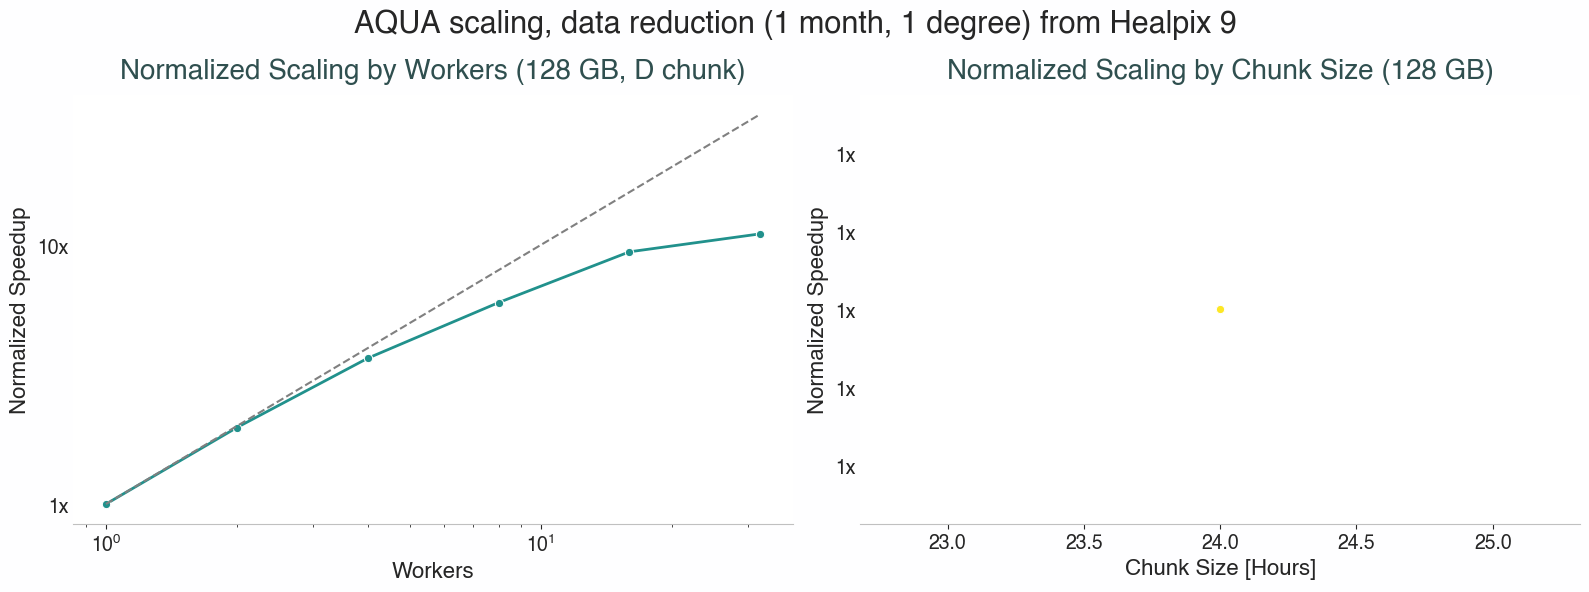

In [60]:
plot_normalized_scaling_and_chunking(results, results_chunk, log_scale=True,
                                     title='AQUA scaling, data reduction (1 month, 1 degree) from Healpix 9')